# Conservative 2D regrid — spherical `s2` manifold

Conservative regridding preserves integrals by computing overlap *areas* between source and target cells. On latitude/longitude grids, the geometry model used for those overlaps matters:

- `"planar"` (default): fast planar shapely intersections in the raw coordinate plane.
- `"cea"`: cylindrical equal-area projection before planar intersection (good spherical area approximation for many workflows).
- `"s2"`: great-circle spherical geometry through [`spherely`](https://github.com/benbovy/spherely), which is the most geometrically faithful option.

This notebook gives a compact, step-by-step view of the workflow:

1. Build a simple analytic source field.
2. Visualize source and target grids.
3. Regrid with each manifold and compare outputs.
4. Verify conservation with a known integral.
5. Show where `s2` and `cea` diverge most.
6. Persist and reload an `s2` regridder for reuse.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import xarray_regrid  # noqa: F401
from xarray_regrid import ConservativeRegridder

## Source field and target grid

We use a smooth test field on a 1° grid,

\[
f(\phi, \lambda) = \cos^2(\phi)\,(1 + 0.15\sin(3\lambda))
\]

where `\phi` is latitude and `\lambda` is longitude. This keeps the latitudinal structure intuitive while introducing longitudinal variability so map comparisons are visually informative.

In [2]:
lat = np.linspace(-89.5, 89.5, 180)
lon = np.linspace(-179.5, 179.5, 360)

src = xr.DataArray(
    (np.cos(np.deg2rad(lat)) ** 2)[:, None]
    * (1.0 + 0.15 * np.sin(3 * np.deg2rad(lon))[None, :]),
    dims=("latitude", "longitude"),
    coords={"latitude": lat, "longitude": lon},
    name="f",
)

target = xr.Dataset(
    coords={
        "latitude": np.linspace(-89, 89, 90),
        "longitude": np.linspace(-179, 179, 180),
    }
)

src

<xarray.DataArray 'f' (latitude: 180, longitude: 360)> Size: 518kB
array([[7.58534061e-05, 7.52561943e-05, 7.46614390e-05, ...,
        7.76434047e-05, 7.70486493e-05, 7.64514375e-05],
       [6.82542028e-04, 6.77168213e-04, 6.71816502e-04, ...,
        6.98648743e-04, 6.93297033e-04, 6.87923218e-04],
       [1.89518011e-03, 1.88025891e-03, 1.86539909e-03, ...,
        1.93990282e-03, 1.92504300e-03, 1.91012179e-03],
       ...,
       [1.89518011e-03, 1.88025891e-03, 1.86539909e-03, ...,
        1.93990282e-03, 1.92504300e-03, 1.91012179e-03],
       [6.82542028e-04, 6.77168213e-04, 6.71816502e-04, ...,
        6.98648743e-04, 6.93297033e-04, 6.87923218e-04],
       [7.58534061e-05, 7.52561943e-05, 7.46614390e-05, ...,
        7.76434047e-05, 7.70486493e-05, 7.64514375e-05]], shape=(180, 360))
Coordinates:
  * latitude   (latitude) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * longitude  (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5

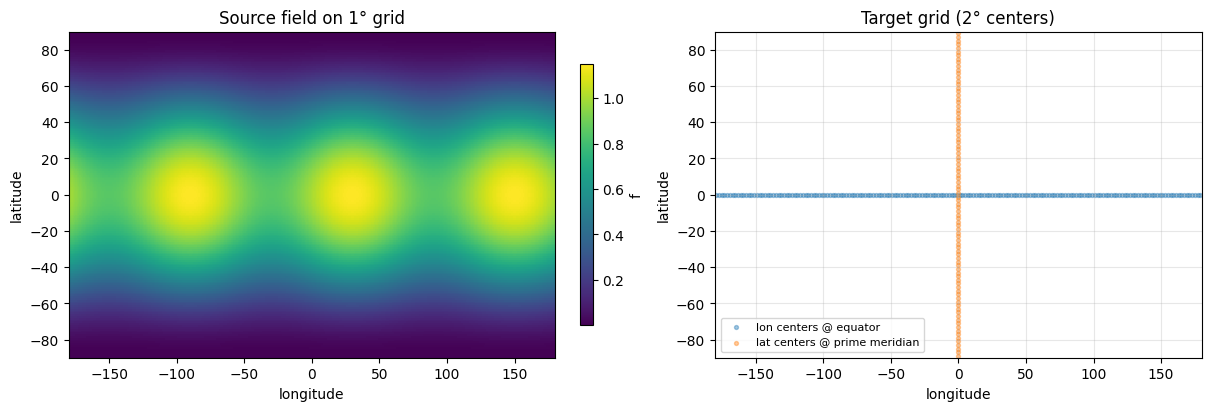

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

src.plot(ax=axes[0], cmap="viridis", cbar_kwargs={"shrink": 0.8})
axes[0].set_title("Source field on 1° grid")

axes[1].set_title("Target grid (2° centers)")
axes[1].set_xlabel("longitude")
axes[1].set_ylabel("latitude")
axes[1].set_xlim(-180, 180)
axes[1].set_ylim(-90, 90)
axes[1].scatter(
    target.longitude.values,
    np.zeros_like(target.longitude.values),
    s=8,
    alpha=0.4,
    label="lon centers @ equator",
)
axes[1].scatter(
    np.zeros_like(target.latitude.values),
    target.latitude.values,
    s=8,
    alpha=0.4,
    label="lat centers @ prime meridian",
)
axes[1].grid(alpha=0.3)
axes[1].legend(loc="lower left", fontsize=8)

## Regrid with each manifold

All three runs use the same source, target, and conservative operator interface; only the manifold changes.

To make the transformation visually obvious, we overlay coarse target-grid lines on each output map.

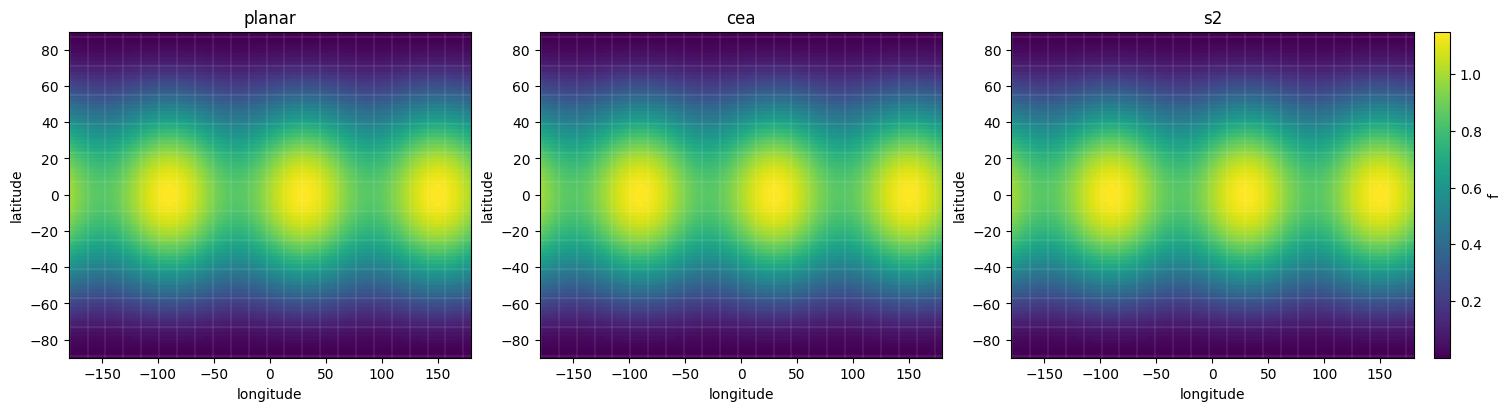

In [4]:
out_planar = src.regrid.conservative_2d(
    target, x_coord="longitude", y_coord="latitude", manifold="planar"
)
out_cea = src.regrid.conservative_2d(
    target, x_coord="longitude", y_coord="latitude", manifold="cea"
)
out_s2 = src.regrid.conservative_2d(
    target, x_coord="longitude", y_coord="latitude", manifold="s2"
)

# Coarse visual guide to the target grid structure.
lat_lines = target.latitude.values[::8]
lon_lines = target.longitude.values[::8]

vmin = float(src.min())
vmax = float(src.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, title, arr in [
    (axes[0], "planar", out_planar),
    (axes[1], "cea", out_cea),
    (axes[2], "s2", out_s2),
]:
    arr.plot(ax=ax, cmap="viridis", vmin=vmin, vmax=vmax, add_colorbar=(ax is axes[2]))
    for y in lat_lines:
        ax.axhline(float(y), color="white", lw=0.25, alpha=0.45)
    for x in lon_lines:
        ax.axvline(float(x), color="white", lw=0.25, alpha=0.45)
    ax.set_title(title)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

## Conservation check against an analytic integral

For this notebook's check field, the dominant term is `\cos^2(lat)`, whose integral over the unit sphere is `8π/3`. We integrate each regridded output against true spherical target-cell areas and compare errors. This is a practical sanity check that conservative weighting behaves as expected.

In [5]:
TRUE = 8 * np.pi / 3


def sph_cell_areas(lat_vals, lon_vals):
    lat_r = np.deg2rad(lat_vals)
    dlat = np.gradient(lat_r)
    dlon = np.gradient(np.deg2rad(lon_vals))
    return (np.sin(lat_r + dlat / 2) - np.sin(lat_r - dlat / 2))[:, None] * dlon[None, :]


a_tgt = sph_cell_areas(target.latitude.values, target.longitude.values)

print(f"{'manifold':>8}  {'integral':>11}  {'|error|':>10}")
for manifold, arr in {
    "planar": out_planar.values,
    "cea": out_cea.values,
    "s2": out_s2.values,
}.items():
    valid = np.isfinite(arr)
    integral = float((arr[valid] * a_tgt[valid]).sum())
    print(f"{manifold:>8}  {integral:>11.6f}  {abs(integral - TRUE):>10.2e}")
print(f"{'truth':>8}  {TRUE:>11.6f}")

manifold     integral     |error|
  planar     8.376836    7.44e-04
     cea     8.377474    1.06e-04
      s2     8.377219    3.61e-04
   truth     8.377580


## Where `s2` and `cea` differ most

At fine resolutions, `cea` and `s2` are often close. The gap becomes easier to see on coarse grids, where great-circle vs projected straight-edge assumptions diverge more strongly.

max |s2 − cea|: 2.23e-03


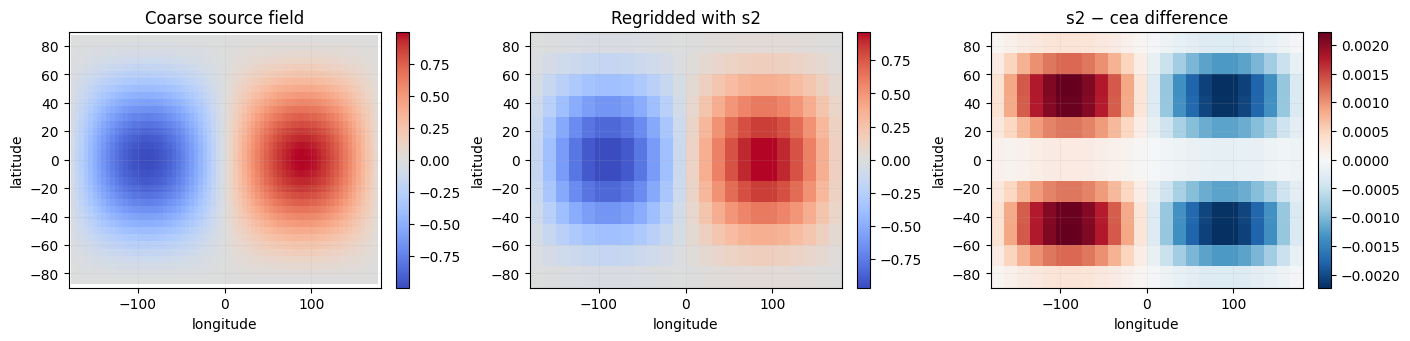

In [6]:
coarse_lat = np.linspace(-85, 85, 35)
coarse_lon = np.linspace(-175, 175, 70)
coarse_src = xr.DataArray(
    np.cos(np.deg2rad(coarse_lat))[:, None] ** 2
    * np.sin(np.deg2rad(coarse_lon))[None, :],
    dims=("latitude", "longitude"),
    coords={"latitude": coarse_lat, "longitude": coarse_lon},
)
coarse_tgt = xr.Dataset(
    coords={
        "latitude": np.linspace(-82.5, 82.5, 12),
        "longitude": np.linspace(-172.5, 172.5, 24),
    }
)

coarse_s2 = coarse_src.regrid.conservative_2d(
    coarse_tgt, x_coord="longitude", y_coord="latitude", manifold="s2"
)
coarse_cea = coarse_src.regrid.conservative_2d(
    coarse_tgt, x_coord="longitude", y_coord="latitude", manifold="cea"
)
diff = coarse_s2 - coarse_cea

fig, axes = plt.subplots(1, 3, figsize=(14, 3.3), constrained_layout=True)
coarse_src.plot(ax=axes[0], cmap="coolwarm")
axes[0].set_title("Coarse source field")
coarse_s2.plot(ax=axes[1], cmap="coolwarm")
axes[1].set_title("Regridded with s2")
diff.plot(ax=axes[2], cmap="RdBu_r", center=0)
axes[2].set_title("s2 − cea difference")
for ax in axes:
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.grid(alpha=0.25, lw=0.4)

print(f"max |s2 − cea|: {float(np.nanmax(np.abs(diff.values))):.2e}")

## Reuse: persist the `s2` regridder

The expensive part is building geometry and overlaps. Save once, reload, and apply repeatedly to fields on the same source/target grids.

In [7]:
rgr = ConservativeRegridder(
    src,
    target,
    x_coord="longitude",
    y_coord="latitude",
    manifold="s2",
)
path = Path(tempfile.gettempdir()) / "s2_regridder.nc"
rgr.to_netcdf(path)
rgr2 = ConservativeRegridder.from_netcdf(path)

print(f"saved {path.stat().st_size / 1024:.0f} KB, manifold={rgr2.manifold!r}")
print(
    "bit-identical forward:",
    np.array_equal(rgr.regrid(src).values, rgr2.regrid(src).values),
)

saved 2312 KB, manifold='s2'
bit-identical forward: True
